# Selecting Top-k Configs from a Screening Sweep

Ranks `(feature_set, mining_setting, granularity)` configs from a
`run_screening_sweep.py` run using the logic in
`thesis.metrics.config_selection`:

1. **Mean LR score** (primary) -- mean of `SCORE_COL` across all evaluated
   windows, per config.
2. **Stability** -- std of that score across windows, used as a *penalty* on
   the ranking (`selection_score = score_mean - LAM * score_std`), not a
   standalone filter.
3. **Floor performance** -- a sanity check applied to the ranked shortlist
   (not baked into the ranking formula): flag any survivor whose worst (or
   10th-percentile) window falls below `FLOOR_THRESHOLD`.
4. **Feature parsimony** -- optional tie-breaker; configs whose
   `selection_score` is within `TIEBREAK_TOL` of each other are reordered by
   ascending feature count.

All thresholds are set in the config cell below -- the module itself takes
them as arguments and hardcodes nothing.

In [17]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

from thesis.paths import ARTIFACTS_DIR
from thesis.metrics.config_selection import (
    summarize_configs,
    rank_configs,
    apply_floor_check,
    select_top_k,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Thresholds

Edit these and re-run below -- nothing past this cell needs to change.

In [18]:
SCENARIO = "cscas"
RUN_ID = None  # e.g. "20260708_043553"; None -> latest run dir for SCENARIO

# "precision" (TP/(TP+FP)) over "auc": with heavy class imbalance (few attacks),
# ROC AUC stays high even as absolute FP counts grow (FPR's TN-heavy denominator
# hides it), so it doesn't track the thing we actually care about -- alert
# fatigue from false positives. Keep an eye on `recall` too (e.g. via the floor
# check below) so this doesn't just reward configs that stopped flagging attacks.
SCORE_COL = "precision"
GROUP_COLS = ["feature_set", "mining_setting", "granularity", "model"]

LAM = 0.5  # selection_score = score_mean - LAM * score_std
K = 10  # shortlist size

FLOOR_COL = "score_min"  # or "score_p10" for a softer floor
# precision across windows in this run spans ~0.65-0.92 (mean ~0.80) -- unlike
# AUC this is NOT clustered near 1.0, so the floor needs to live in that range.
FLOOR_THRESHOLD = 0.6

TIEBREAK_COL = "n_features_mean"
TIEBREAK_TOL = 0.0  # >0 to prefer smaller schemas among near-tied configs

In [19]:
sweep_dir = ARTIFACTS_DIR / "experiments" / "screening_sweep" / SCENARIO

if RUN_ID:
    run_dir = sweep_dir / RUN_ID
else:
    run_dirs = [p for p in sweep_dir.iterdir() if p.is_dir()]
    run_dir = sorted(run_dirs)[-1]

per_window = pd.read_csv(run_dir / "per_window_results.csv")

# Not in the CSV, but the formula is already the codebase's own convention
# for this metric (thesis/experiments/_shared.py's metrics_at_threshold) --
# needed for section 8's combined metric view below.
per_window["fpr"] = per_window["fp"] / (per_window["fp"] + per_window["tn"])

print(f"Loaded {len(per_window)} rows from {run_dir}")
per_window.head()

Loaded 205 rows from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/20260709_020952


,scenario,granularity,window_id,win_start_frac,win_end_frac,n_alert_groups,n_attack,n_train,n_test,feature_set,mining_setting,model,n_features,auc,f1,accuracy,precision,recall,tp,fp,tn,fn,single_class_split,mining_cache_hit,fpr
0,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,baseline,NaN,logreg,41,0.998034,0.717017,0.992929,0.569909,0.966495,375,283,41189,13,False,NaN,0.006824
1,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md3,logreg,331,0.983405,0.806034,0.995700,0.692593,0.963918,374,166,41306,14,False,True,0.004003
2,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md4,logreg,332,0.983613,0.853575,0.996918,0.762677,0.969072,376,117,41355,12,False,False,0.002821
3,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr3.0_md5,logreg,334,0.939744,0.844907,0.996799,0.766807,0.940722,365,111,41361,23,False,False,0.002677
4,cscas,0.1,0,0.0,0.1,139532,1765,97672,41860,symbolic,gr4.0_md3,logreg,313,0.983434,0.811159,0.995796,0.694853,0.974227,378,166,41306,10,False,False,0.004003


## 1. Summarize + rank

In [20]:
summary = summarize_configs(
    per_window, score_col=SCORE_COL, group_cols=GROUP_COLS
)
ranked = rank_configs(
    summary,
    lam=LAM,
    tiebreak_col=TIEBREAK_COL,
    tiebreak_tol=TIEBREAK_TOL,
)
ranked.head(15)

,feature_set,mining_setting,granularity,model,score_mean,score_std,score_min,score_max,n_windows,score_cv,score_p10,n_features_mean,selection_score
0,symbolic,gr5.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,299.000000,0.822590
1,symbolic,gr4.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,337.400000,0.822590
2,symbolic,gr3.0_md5,0.1,logreg,0.850571,0.056252,0.766807,0.916919,10,0.066134,0.777111,376.600000,0.822445
3,symbolic,gr3.0_md5,0.2,logreg,0.836168,0.046134,0.801265,0.888471,3,0.055173,0.804765,380.666667,0.813101
4,symbolic,gr4.0_md5,0.2,logreg,0.824711,0.039483,0.789836,0.891263,5,0.047875,0.794408,347.800000,0.804969
5,symbolic,gr5.0_md5,0.2,logreg,0.824562,0.039288,0.789655,0.890704,5,0.047647,0.794299,280.400000,0.804918
6,symbolic,gr4.0_md4,0.1,logreg,0.836010,0.065864,0.756681,0.916667,10,0.078784,0.760252,336.100000,0.803078
7,symbolic,gr3.0_md4,0.1,logreg,0.835875,0.065828,0.756681,0.916667,10,0.078753,0.762078,375.300000,0.802961
8,symbolic,gr5.0_md4,0.1,logreg,0.835351,0.066549,0.755556,0.916667,10,0.079666,0.756568,297.700000,0.802076
9,symbolic,gr3.0_md5,0.5,logreg,0.804532,0.010449,0.797143,0.811921,2,0.012988,0.798621,348.000000,0.799307


## 2. Top-k shortlist + floor check

In [21]:
shortlist = select_top_k(ranked, k=K)
shortlist = apply_floor_check(
    shortlist, floor_threshold=FLOOR_THRESHOLD, floor_col=FLOOR_COL
)

n_failing = (~shortlist["passes_floor"]).sum()
if n_failing:
    print(
        f"{n_failing}/{K} shortlisted configs fail the floor check "
        f"({FLOOR_COL} < {FLOOR_THRESHOLD}) despite a strong mean -- "
        "inspect below before finalizing."
    )
else:
    print(f"All {K} shortlisted configs clear the floor check.")

shortlist

All 10 shortlisted configs clear the floor check.


,feature_set,mining_setting,granularity,model,score_mean,score_std,score_min,score_max,n_windows,score_cv,score_p10,n_features_mean,selection_score,passes_floor
0,symbolic,gr5.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,299.000000,0.822590,True
1,symbolic,gr4.0_md5,0.1,logreg,0.850673,0.056168,0.766807,0.916919,10,0.066027,0.777111,337.400000,0.822590,True
2,symbolic,gr3.0_md5,0.1,logreg,0.850571,0.056252,0.766807,0.916919,10,0.066134,0.777111,376.600000,0.822445,True
3,symbolic,gr3.0_md5,0.2,logreg,0.836168,0.046134,0.801265,0.888471,3,0.055173,0.804765,380.666667,0.813101,True
4,symbolic,gr4.0_md5,0.2,logreg,0.824711,0.039483,0.789836,0.891263,5,0.047875,0.794408,347.800000,0.804969,True
5,symbolic,gr5.0_md5,0.2,logreg,0.824562,0.039288,0.789655,0.890704,5,0.047647,0.794299,280.400000,0.804918,True
6,symbolic,gr4.0_md4,0.1,logreg,0.836010,0.065864,0.756681,0.916667,10,0.078784,0.760252,336.100000,0.803078,True
7,symbolic,gr3.0_md4,0.1,logreg,0.835875,0.065828,0.756681,0.916667,10,0.078753,0.762078,375.300000,0.802961,True
8,symbolic,gr5.0_md4,0.1,logreg,0.835351,0.066549,0.755556,0.916667,10,0.079666,0.756568,297.700000,0.802076,True
9,symbolic,gr3.0_md5,0.5,logreg,0.804532,0.010449,0.797143,0.811921,2,0.012988,0.798621,348.000000,0.799307,True


## 3. Save shortlist for Experiment 2

Writes the standard shortlist file format `thesis.metrics.shortlist.load_shortlist`
expects (`feature_set,mining_setting,granularity,model` columns -- extra columns
like `score_mean` are allowed but not required, so this is just the shortlist
DataFrame trimmed to those 4). Hand-edit the saved CSV afterward to add/drop rows
if you want to override the automatic top-k selection.

In [22]:
SHORTLIST_PATH = sweep_dir / "shortlist.csv"

shortlist_out = shortlist[["feature_set", "mining_setting", "granularity", "model"]]
shortlist_out.to_csv(SHORTLIST_PATH, index=False)
print(f"Saved shortlist ({len(shortlist_out)} configs) → {SHORTLIST_PATH}")
shortlist_out

Saved shortlist (10 configs) → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/shortlist.csv


,feature_set,mining_setting,granularity,model
0,symbolic,gr5.0_md5,0.1,logreg
1,symbolic,gr4.0_md5,0.1,logreg
2,symbolic,gr3.0_md5,0.1,logreg
3,symbolic,gr3.0_md5,0.2,logreg
4,symbolic,gr4.0_md5,0.2,logreg
5,symbolic,gr5.0_md5,0.2,logreg
6,symbolic,gr4.0_md4,0.1,logreg
7,symbolic,gr3.0_md4,0.1,logreg
8,symbolic,gr5.0_md4,0.1,logreg
9,symbolic,gr3.0_md5,0.5,logreg


## 4. Visualize: mean ± std, floor threshold

Every config the sweep considered, not a top-N slice -- for a thesis
defense, the full ranking (including the low-scoring tail and the
`baseline` reference configs) needs to be visible, not just the winners.
No plot in this notebook highlights the top-`K` shortlist -- that outcome
is already shown in sections 2/3; every plot here just distinguishes
`baseline` from `other`.

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_44274/2760544195.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_44274/2760544195.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(


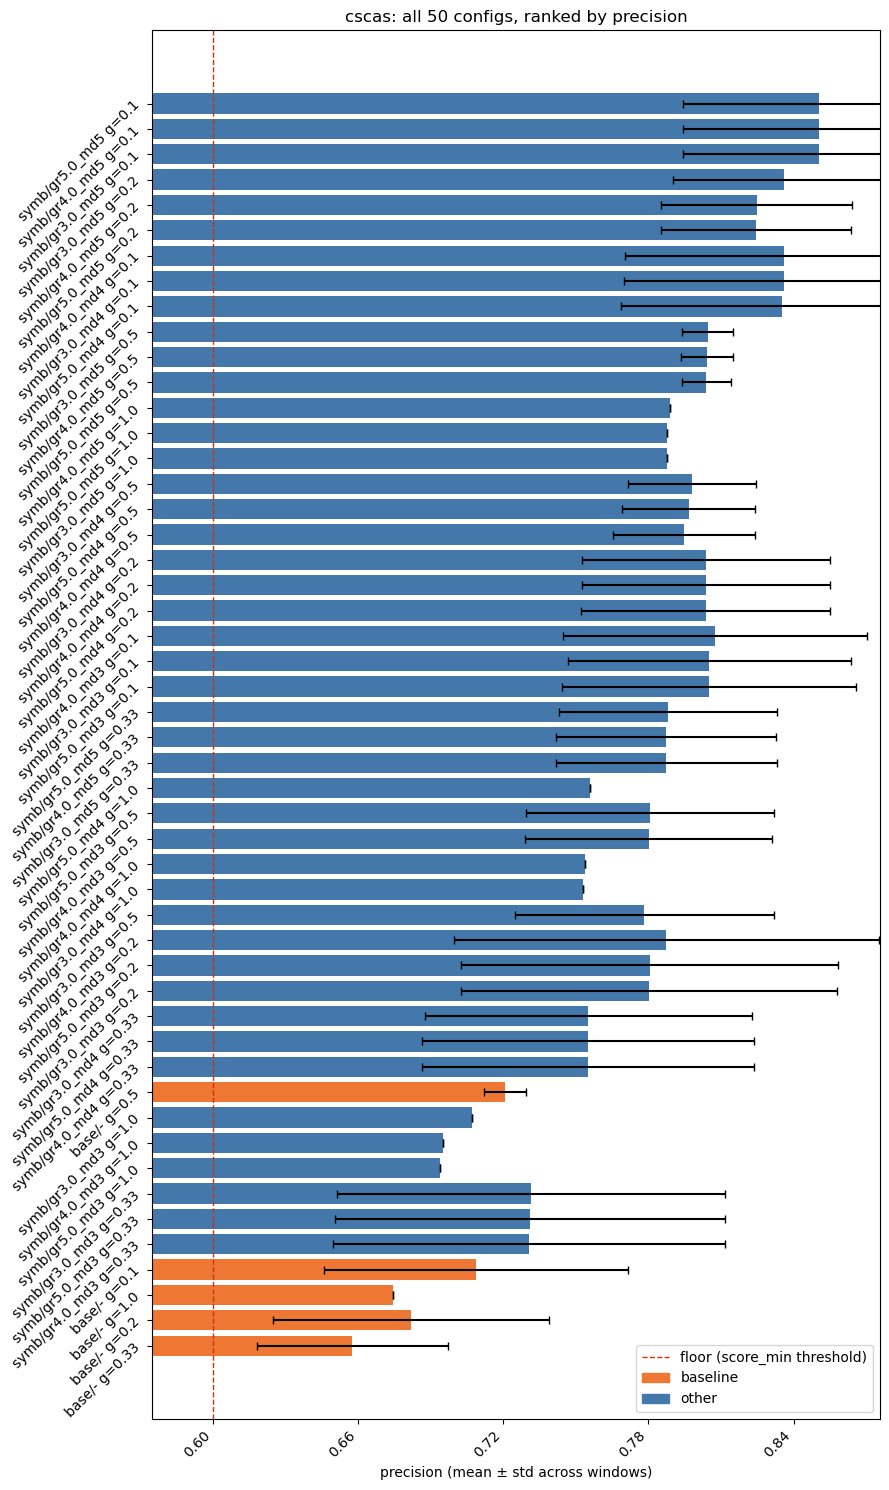

In [23]:
PLOT_TOP_N = None  # None -> show every config; set an int to cap for a quick look

plot_df = (ranked if PLOT_TOP_N is None else ranked.head(PLOT_TOP_N)).copy()
plot_df["label"] = (
    plot_df["feature_set"].astype(str).str.slice(0, 4)  # "baseline"->"base", "symbolic"->"symb"
    + "/"
    + plot_df["mining_setting"].fillna("-").astype(str)
    + " g="
    + plot_df["granularity"].astype(str)
)

BASELINE_COLOR = "#EE7733"
OTHER_COLOR = "#4477AA"
FLOOR_LINE_COLOR = "#CC3311"

# No shortlist highlighting anywhere in this notebook -- just baseline vs.
# other. Reused by sections 5 and 8 below.
colors = [
    BASELINE_COLOR if row.feature_set == "baseline" else OTHER_COLOR
    for row in plot_df.itertuples()
]
legend_handles = [
    Patch(color=BASELINE_COLOR, label="baseline"),
    Patch(color=OTHER_COLOR, label="other"),
]

fig, ax = plt.subplots(figsize=(9, 0.28 * len(plot_df) + 1))
ax.barh(
    plot_df["label"],
    plot_df["score_mean"],
    xerr=plot_df["score_std"],
    color=colors,
    capsize=3,
)
floor_line = ax.axvline(
    FLOOR_THRESHOLD, color=FLOOR_LINE_COLOR, linestyle="--", linewidth=1,
    label=f"floor ({FLOOR_COL} threshold)",
)
ax.invert_yaxis()
ax.set_xlabel(f"{SCORE_COL} (mean ± std across windows)")
ax.set_title(f"{SCENARIO}: all {len(plot_df)} configs, ranked by {SCORE_COL}")
ax.legend(handles=[floor_line, *legend_handles], loc="lower right")
ax.xaxis.set_major_locator(mticker.MaxNLocator(6))

# Zoomed to the band this run's scores actually occupy -- baseline configs
# are included in plot_df now, so this widens automatically to cover their
# (typically lower) scores too, rather than assuming everything clusters
# near 1.0.
x_lo = min((plot_df["score_mean"] - plot_df["score_std"]).min(), FLOOR_THRESHOLD)
x_hi = plot_df["score_mean"].max()
margin = (x_hi - x_lo) * 0.1 or 0.001
ax.set_xlim(x_lo - margin, x_hi + margin)
ax.set_xticklabels(
    [f"{x:.2f}" for x in ax.get_xticks()],
    rotation=45,
    ha="right",
)
ax.set_yticklabels(
    [f"{y.get_text()}" for i, y in enumerate(ax.get_yticklabels())],
    rotation=45,
    ha="right",
)
fig.tight_layout()

## 6. Symbolic vs. baseline comparison

Every screening-sweep window has a `feature_set="baseline"` row (no symbolic
features) alongside each `feature_set="symbolic"` row, evaluated on the exact
same train/test split. `thesis.metrics.baseline_comparison.pair_with_baseline`
joins each symbolic row to its baseline row from that same
(granularity, window_id, model), then `summarize_comparison` averages the
per-window deltas into one row per symbolic config:

- `auc_delta`, `precision_delta`, `recall_delta` -- symbolic minus baseline.
- `fp_reduction` -- baseline FP count minus symbolic FP count (positive =
  symbolic raised fewer false alarms).
- `fn_increase` -- symbolic FN count minus baseline FN count (positive =
  symbolic missed more attacks than baseline on that window; the cost side of
  any FP reduction).

Every symbolic config in `plot_df` (section 4 -- all of them, unless
`PLOT_TOP_N` is capped), in the same order. `baseline` rows themselves are
excluded here -- a baseline config has no baseline to compare itself
against; they're the reference point, not a comparison subject.

In [25]:
from thesis.metrics.baseline_comparison import pair_with_baseline, summarize_comparison

paired = pair_with_baseline(per_window)
comparison = summarize_comparison(paired)

# Same configs/order as plot_df (section 4), restricted to symbolic rows --
# a baseline config has no baseline to compare itself against.
compare_table = plot_df[plot_df["feature_set"] == "symbolic"][
    [*GROUP_COLS, "label", "score_mean"]
].merge(comparison, on=["mining_setting", "granularity", "model"], how="left")

compare_table

,feature_set,mining_setting,granularity,model,label,score_mean,n_windows,auc_delta_mean,precision_delta_mean,recall_delta_mean,fp_reduction_mean,fp_reduction_pct_mean,fn_increase_mean
0,symbolic,gr5.0_md5,0.10,logreg,symb/gr5.0_md5 g=0.1,0.850673,10,-0.009199,0.141778,-0.034281,163.500000,0.567694,26.600000
1,symbolic,gr4.0_md5,0.10,logreg,symb/gr4.0_md5 g=0.1,0.850673,10,-0.009199,0.141778,-0.034281,163.500000,0.567694,26.600000
2,symbolic,gr3.0_md5,0.10,logreg,symb/gr3.0_md5 g=0.1,0.850571,10,-0.009198,0.141676,-0.034281,163.400000,0.567299,26.600000
3,symbolic,gr3.0_md5,0.20,logreg,symb/gr3.0_md5 g=0.2,0.836168,3,-0.000698,0.147895,-0.013788,307.666667,0.572920,19.666667
4,symbolic,gr4.0_md5,0.20,logreg,symb/gr4.0_md5 g=0.2,0.824711,5,-0.000479,0.142841,-0.006001,317.000000,0.537121,8.600000
5,symbolic,gr5.0_md5,0.20,logreg,symb/gr5.0_md5 g=0.2,0.824562,5,-0.000434,0.142693,-0.006218,316.800000,0.536787,8.800000
6,symbolic,gr4.0_md4,0.10,logreg,symb/gr4.0_md4 g=0.1,0.836010,10,-0.004918,0.127115,-0.023933,150.000000,0.509848,21.700000
7,symbolic,gr3.0_md4,0.10,logreg,symb/gr3.0_md4 g=0.1,0.835875,10,-0.005030,0.126980,-0.023675,149.700000,0.508805,21.600000
8,symbolic,gr5.0_md4,0.10,logreg,symb/gr5.0_md4 g=0.1,0.835351,10,-0.004883,0.126456,-0.024191,149.500000,0.508182,21.800000
9,symbolic,gr3.0_md5,0.50,logreg,symb/gr3.0_md5 g=0.5,0.804532,2,-0.015634,0.083858,-0.011475,556.000000,0.378211,35.500000


## 7. Visualize: AUC / FP reduction / FN increase vs. baseline

Every symbolic config, same order as the plots above. Positive
`fp_reduction` (fewer false alarms) is the payoff; positive `fn_increase`
(more missed attacks) is the cost -- read the two side by side, not just the
AUC delta, since AUC can look flat while precision-driving FP counts move a
lot (see `SCORE_COL`'s rationale in the thresholds cell).

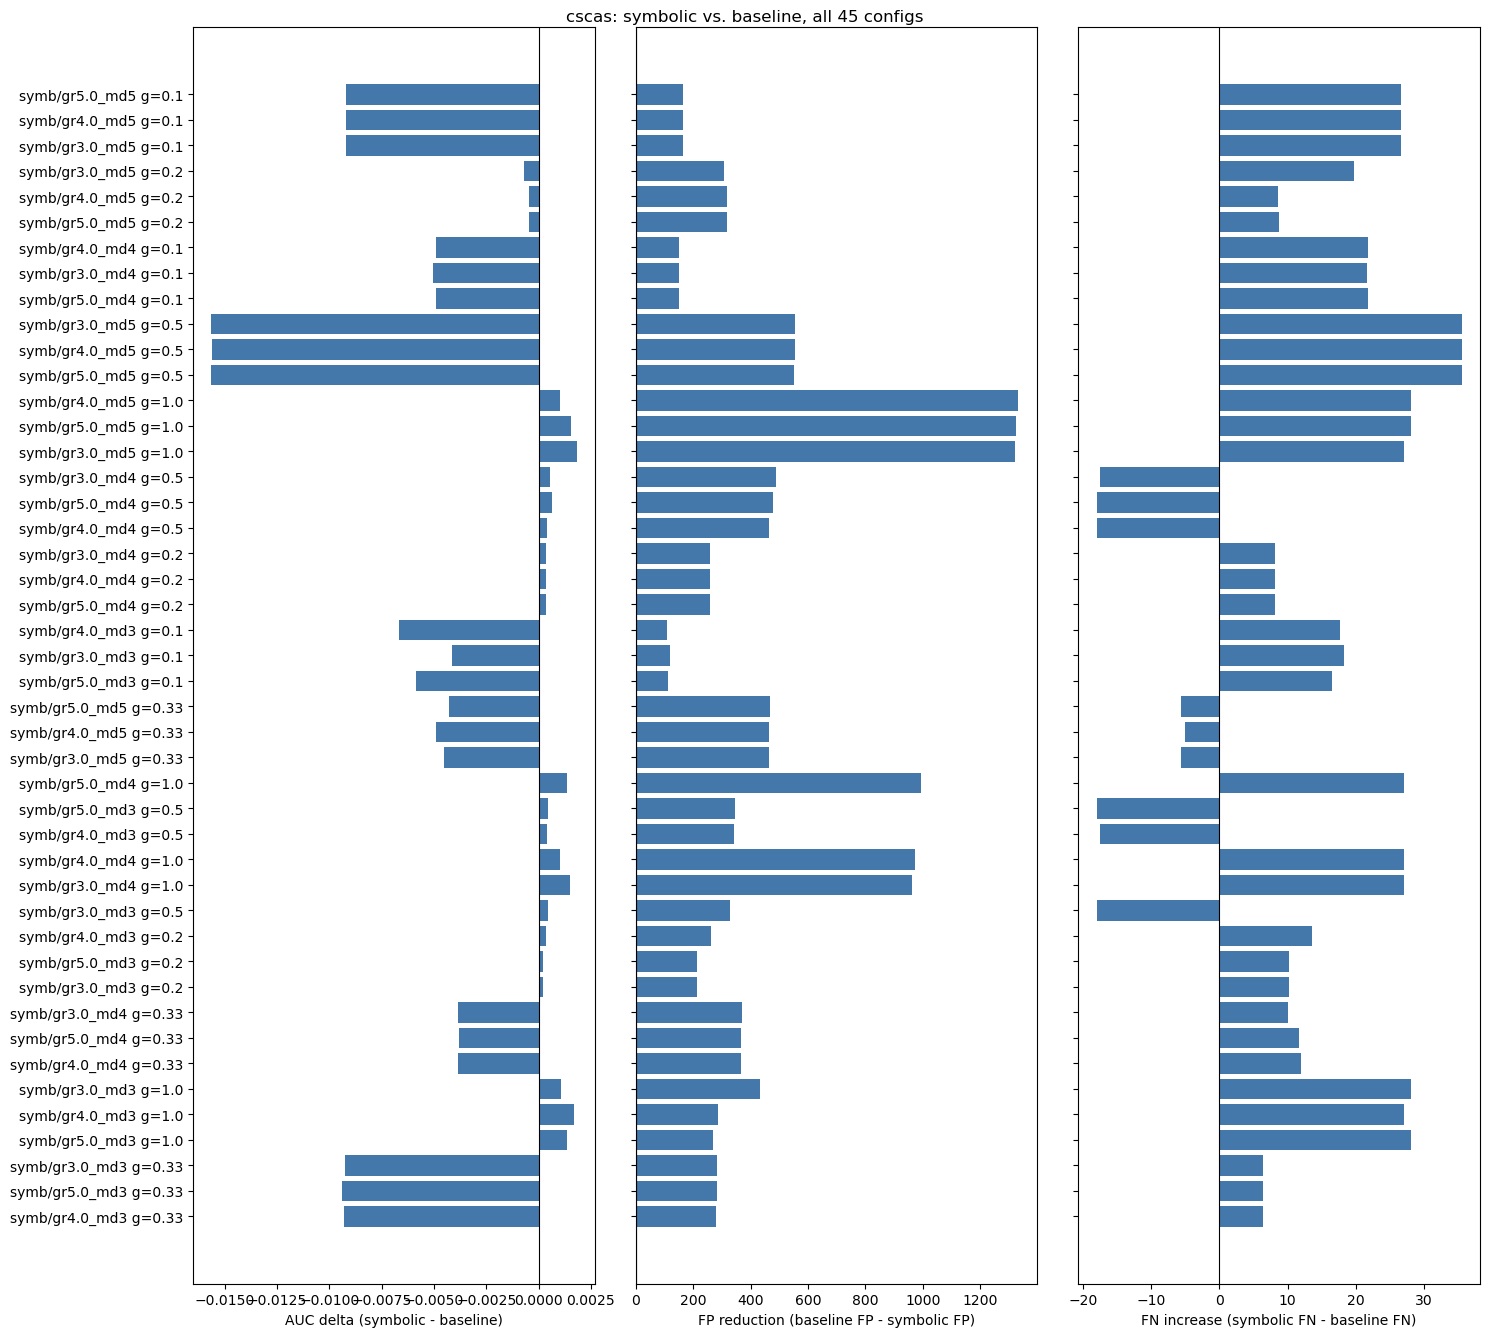

In [26]:
plot_compare = compare_table.dropna(subset=["auc_delta_mean"]).reset_index(drop=True)

fig, axes = plt.subplots(
    1, 3, figsize=(15, 0.28 * len(plot_compare) + 1), sharey=True
)

axes[0].barh(plot_compare["label"], plot_compare["auc_delta_mean"], color=OTHER_COLOR)
axes[0].set_xlabel("AUC delta (symbolic - baseline)")

axes[1].barh(
    plot_compare["label"], plot_compare["fp_reduction_mean"], color=OTHER_COLOR
)
axes[1].set_xlabel("FP reduction (baseline FP - symbolic FP)")

axes[2].barh(
    plot_compare["label"], plot_compare["fn_increase_mean"], color=OTHER_COLOR
)
axes[2].set_xlabel("FN increase (symbolic FN - baseline FN)")

for ax in axes:
    ax.axvline(0, color="black", linewidth=0.8)
axes[0].invert_yaxis()  # shared y-axis: inverting one flips all three
fig.suptitle(f"{SCENARIO}: symbolic vs. baseline, all {len(plot_compare)} configs")
fig.tight_layout()

## 8. Combined view: AUC / Precision / Recall / FPR / FN increase, one plot per granularity

Sections 4 and 5 show `SCORE_COL` (precision) and recall as two separate
figures -- easy to miss that a config topping the precision ranking isn't
necessarily near the top on recall. This puts all five metrics side by side
with a **shared y-axis** so a single config's row can be scanned across
panels at a glance.

Split into one figure **per granularity** rather than one figure mixing
every granularity together: each granularity has its own `baseline` row,
and stacking all granularities into a single global ranking scatters those
baselines throughout the list, making it hard to tell whether *this*
granularity's symbolic configs actually beat *its own* baseline. Within
each granularity's figure, configs are sorted by `score_mean` (the same
metric section 4 ranks by), so that granularity's baseline lands wherever
it actually falls relative to its own symbolic configs.

The first four panels (AUC, Precision, Recall, FPR) are raw mean ± std
values (not deltas vs. baseline) -- FPR is the one where *lower* is better,
called out in its axis label so it doesn't get misread the same direction
as the other three. **FN increase is different**: it isn't a raw per-window
column at all -- it's the same paired delta sections 6/7 use
(`thesis.metrics.baseline_comparison.pair_with_baseline`: each symbolic
row's FN count minus its own baseline's FN count, same window), so it's
only defined for symbolic configs. `baseline` rows get no bar in that one
panel (nothing to compare a baseline against itself), not a misleading zero.

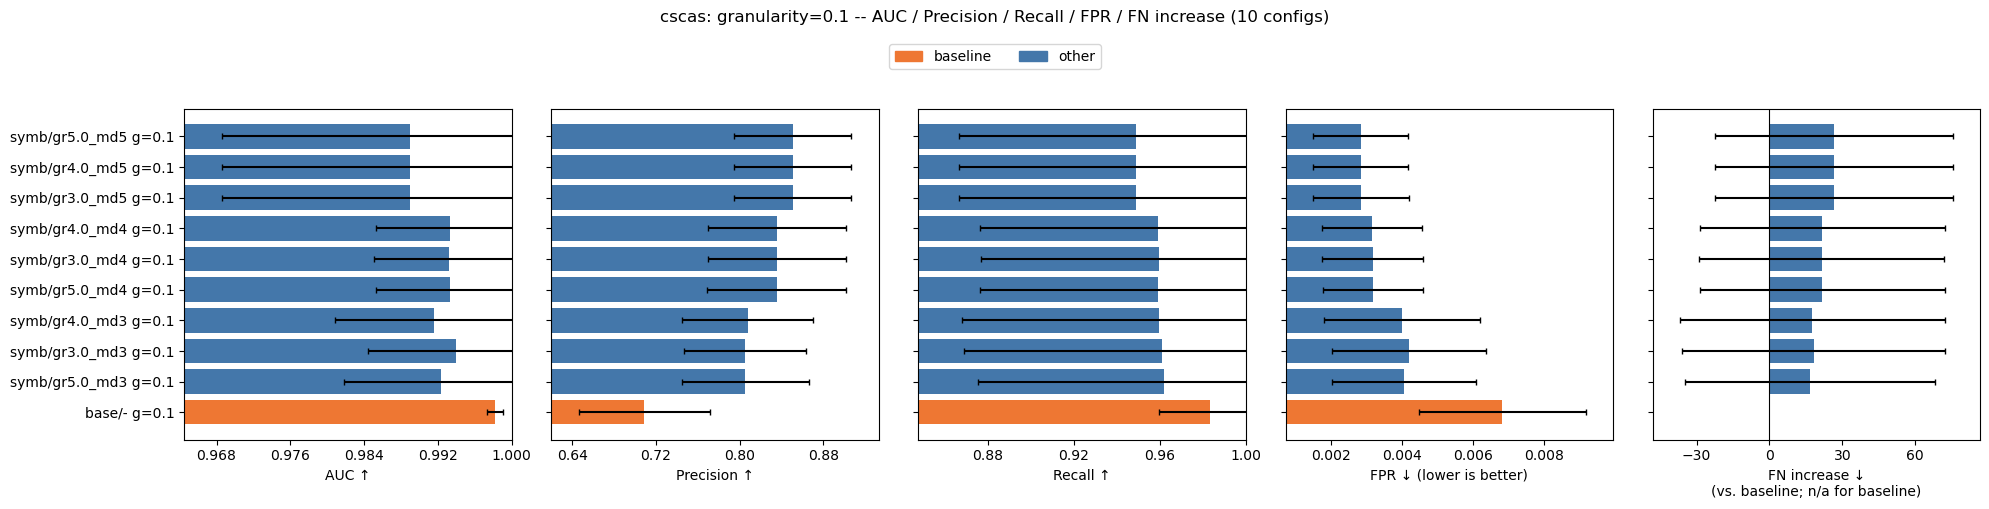

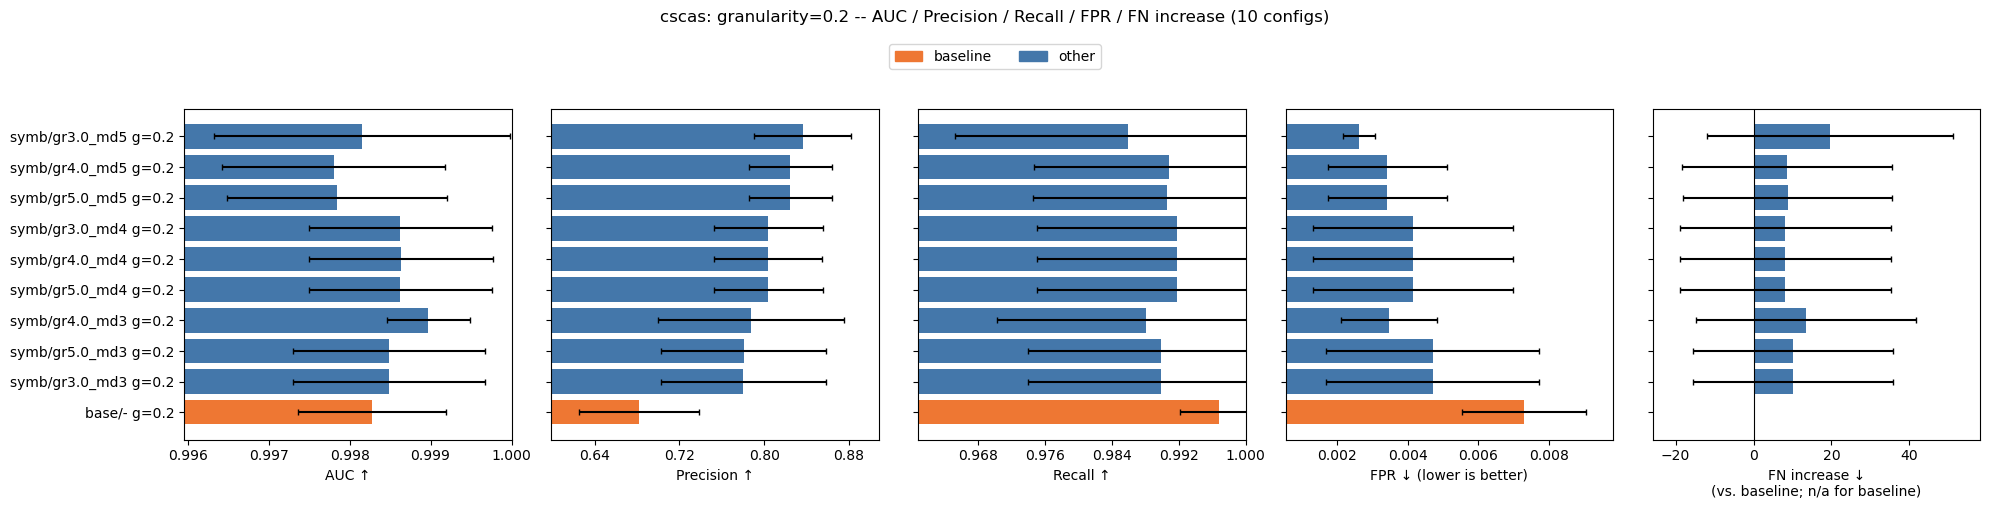

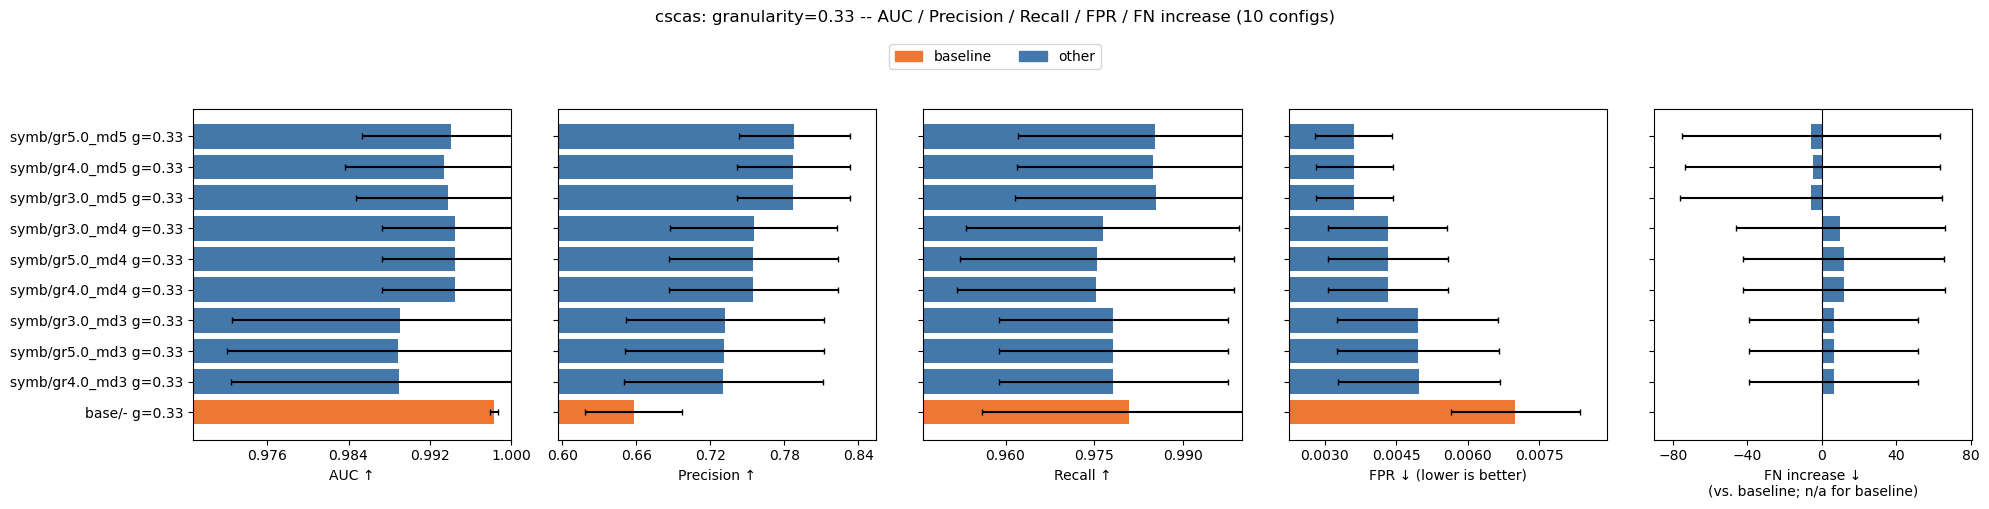

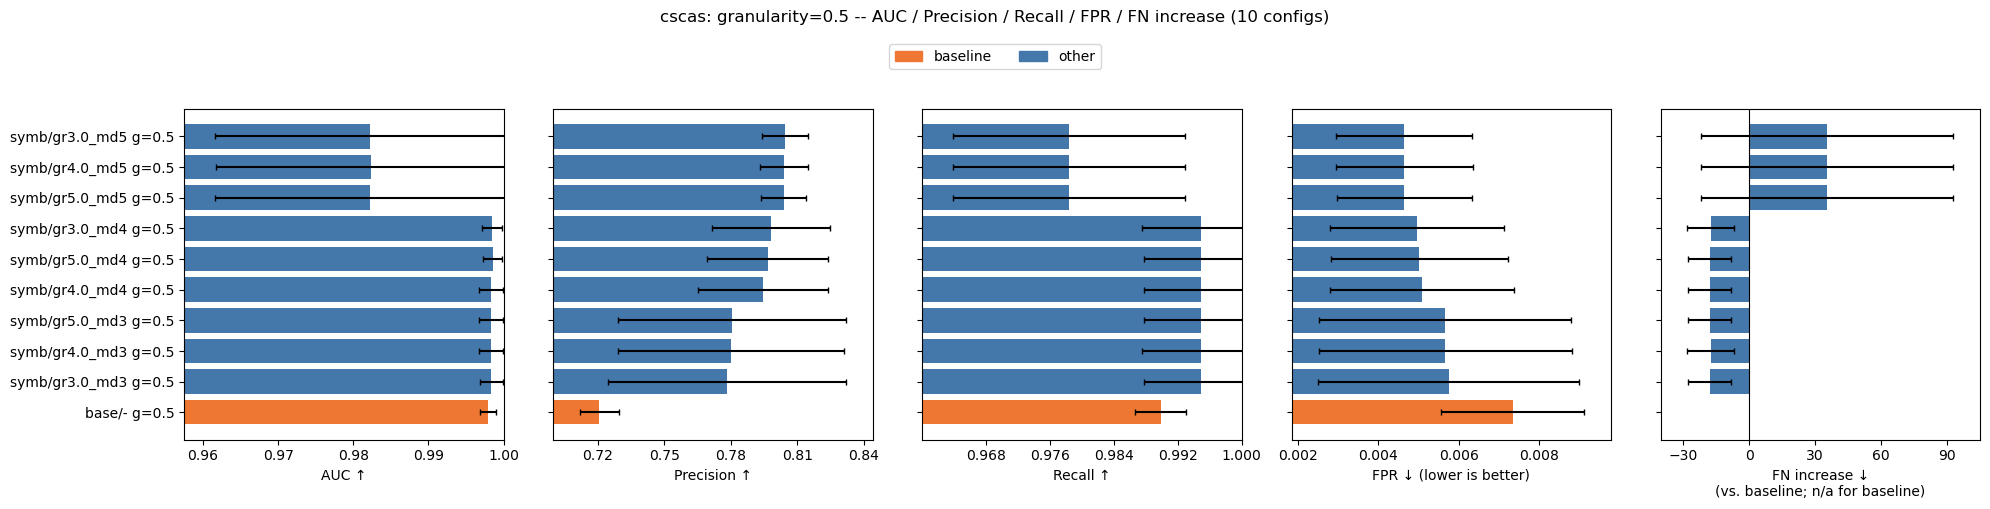

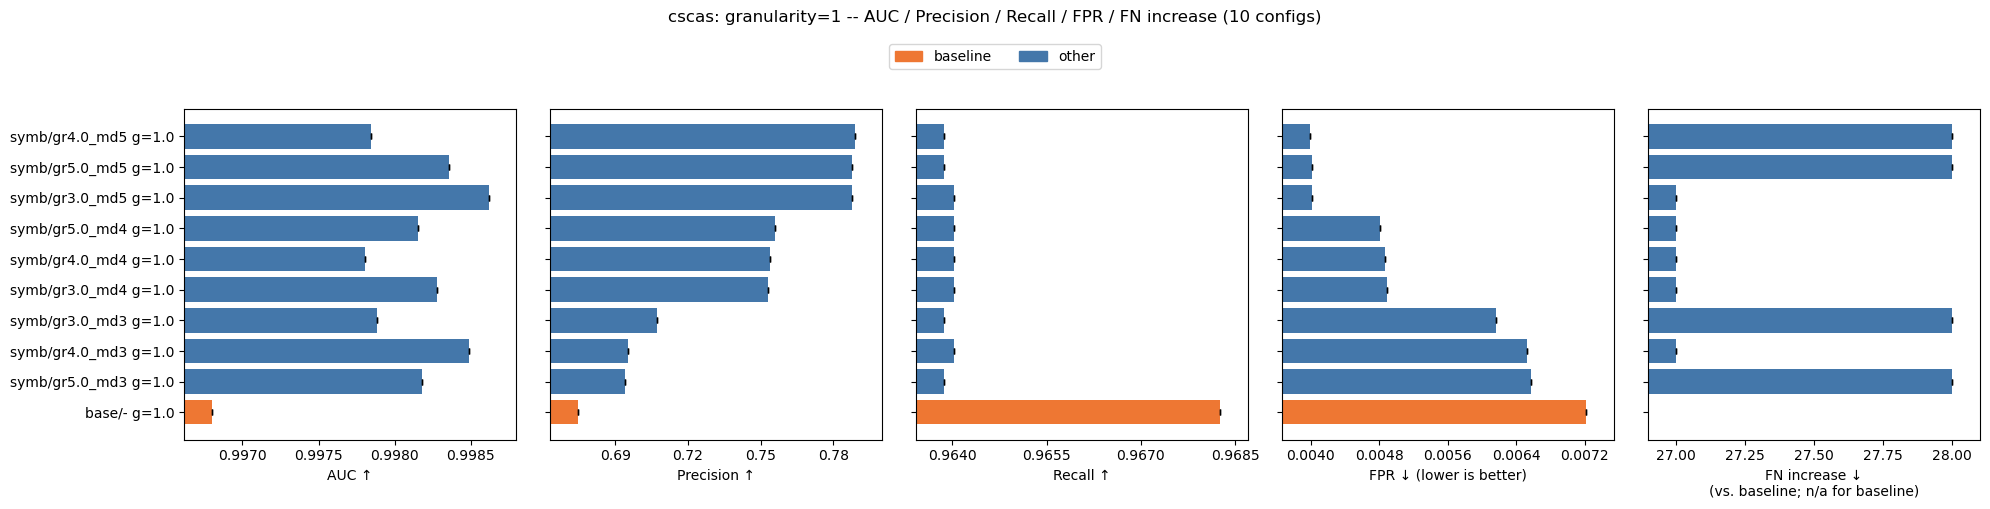

In [27]:
RAW_METRIC_PANELS = [
    ("auc", "AUC ↑"),
    ("precision", "Precision ↑"),
    ("recall", "Recall ↑"),
    ("fpr", "FPR ↓ (lower is better)"),
]

metrics_plot_df = plot_df[[*GROUP_COLS, "label", "score_mean"]].copy()
for metric, _ in RAW_METRIC_PANELS:
    metric_summary = summarize_configs(
        per_window, score_col=metric, group_cols=GROUP_COLS
    ).rename(columns={"score_mean": f"{metric}_mean", "score_std": f"{metric}_std"})
    metrics_plot_df = metrics_plot_df.merge(
        metric_summary[[*GROUP_COLS, f"{metric}_mean", f"{metric}_std"]],
        on=GROUP_COLS,
        how="left",
    )

# FN increase isn't a raw per_window column -- it's the paired delta
# sections 6/7 use (each symbolic row's FN count minus its own baseline's,
# same (granularity, window_id, model)). Only defined for symbolic configs,
# so baseline rows get NaN here; matplotlib's barh silently skips a NaN bar
# rather than drawing a misleading zero, leaving that row blank instead.
fn_increase_summary = (
    pair_with_baseline(per_window)
    .groupby(["mining_setting", "granularity", "model"], dropna=False)["fn_increase"]
    .agg(fn_increase_mean="mean", fn_increase_std="std")
    .reset_index()
)
fn_increase_summary["fn_increase_std"] = fn_increase_summary["fn_increase_std"].fillna(0.0)
metrics_plot_df = metrics_plot_df.merge(
    fn_increase_summary, on=["mining_setting", "granularity", "model"], how="left"
)

METRIC_PANELS = RAW_METRIC_PANELS + [
    ("fn_increase", "FN increase ↓\n(vs. baseline; n/a for baseline)")
]
# Panels bounded to [0, 1] (rates) get their zoom clipped to that range;
# fn_increase is an unbounded count delta, so it isn't.
BOUNDED_METRICS = {"auc", "precision", "recall", "fpr"}

for gran in sorted(metrics_plot_df["granularity"].unique()):
    sub = metrics_plot_df[metrics_plot_df["granularity"] == gran].sort_values(
        "score_mean", ascending=False
    )
    sub_colors = [
        BASELINE_COLOR if fs == "baseline" else OTHER_COLOR for fs in sub["feature_set"]
    ]

    fig, axes = plt.subplots(
        1,
        len(METRIC_PANELS),
        figsize=(4 * len(METRIC_PANELS), 0.3 * len(sub) + 1.5),
        sharey=True,
    )
    for ax, (metric, xlabel) in zip(axes, METRIC_PANELS):
        means = sub[f"{metric}_mean"]
        stds = sub[f"{metric}_std"].fillna(0)
        ax.barh(sub["label"], means, xerr=stds, color=sub_colors, capsize=2)
        ax.set_xlabel(xlabel)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(5))

        # Zoom to the band this panel's bars actually occupy (mean +/- std,
        # skipping NaN e.g. fn_increase's baseline rows) instead of the
        # default 0-based view -- these metrics cluster tightly (AUC/recall
        # near 1.0, FPR near 0), so starting from 0 buries the differences
        # that actually separate the configs.
        x_lo = (means - stds).min()
        x_hi = (means + stds).max()
        margin = (x_hi - x_lo) * 0.1 or 0.001
        if metric in BOUNDED_METRICS:
            ax.set_xlim(max(x_lo - margin, 0.0), min(x_hi + margin, 1.0))
        else:
            ax.set_xlim(x_lo - margin, x_hi + margin)
    axes[-1].axvline(0, color="black", linewidth=0.8)  # fn_increase: +/- both meaningful

    axes[0].invert_yaxis()  # shared y-axis: inverting one flips all panels
    fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(
        f"{SCENARIO}: granularity={gran:g} -- AUC / Precision / Recall / FPR / FN increase ({len(sub)} configs)",
        y=1.12,
    )
    fig.tight_layout()

## 9. Parameter importance: which knobs matter?

Evidence for fixing some sweep axes and only varying the rest in Experiments
2-4: `thesis.metrics.sensitivity.parameter_importance` runs a one-way ANOVA
of `score_mean` (section 1) against each parameter's levels, marginalized
over every other parameter. It and `main_effects` work on any `param_cols`
already in the dataframe -- no knowledge of where those columns came from.

One wrinkle: this sweep's tunable thresholds (`min_growth_rate`,
`max_depth`) are bundled into one opaque `mining_setting` name (e.g.
`"gr3.0_md5"`). `expand_named_setting` unpacks them first, using a `{name:
{parameter: value}}` map built by `mining_setting_param_map` from the
loaded `MiningSettingSpec` objects (not a regex on the name, so it stays
correct if the YAML changes). The same two helpers apply as-is to any other
sweep in this codebase that shares this bundling (`temporal_decay`,
`rolling_walk_forward`, `monitor_drift`).

**eta²** = `SS_between / SS_total`: the fraction of `score_mean`'s spread
across all configs explained by one parameter's level, holding the rest
constant. E.g. `granularity` at eta²≈0.38 means 38% of the variance in mean
precision across ~50 configs comes from which granularity was used. It's
0-1 and comparable across parameters regardless of level count, unlike the
raw F-statistic. `effect_range` is the same idea in `SCORE_COL`'s units;
`p_value` is the ANOVA significance test over config-level means (not
per-window samples).

`effect_size_label` labels eta² against Cohen's (1988) convention --
negligible (<0.01), small (≥0.01), medium (≥0.06), large (≥0.14) -- shown
as bands below and as an `effect_size` column. That's a separate reference
scale from `IMPORTANT_ETA_THRESHOLD` below, this notebook's own cutoff for
the vary/fix call.

A parameter with one level here (e.g. `model` -- only `logreg` was swept)
comes back `n_levels=1` / `NaN` / `"n/a"`: "not screened", not
"unimportant". Same for any `AttributeMiningConfig` field the YAML never
varies.

In [28]:
from thesis.config import load_mining_settings
from thesis.metrics.sensitivity import (
    EFFECT_SIZE_THRESHOLDS,
    effect_size_label,
    expand_named_setting,
    main_effects,
    mining_setting_param_map,
    parameter_importance,
)
from thesis.paths import ROOT

# eta_squared at/above this -> "moves the score enough to keep varying it in
# Experiments 2-4"; below it (or not screened, e.g. model) -> candidate to
# fix at the shortlist's winning level. 0.05 is a conventional small-effect
# cutoff (Cohen), not derived from this data -- revisit if the ranking looks
# borderline.
IMPORTANT_ETA_THRESHOLD = 0.05

MINING_SETTINGS_PATH = ROOT / "src" / "thesis" / "configs" / "screening_mining_settings.yaml"
mining_settings = load_mining_settings(MINING_SETTINGS_PATH)
mining_param_map = mining_setting_param_map(mining_settings)

summary_expanded = expand_named_setting(summary, mining_param_map, col="mining_setting")

# Every AttributeMiningConfig field the YAML's named settings carry (varied
# or not) becomes its own column above -- pull the full set from the map
# itself rather than hand-listing "min_growth_rate, max_depth", so a third
# axis added to the YAML later shows up here automatically.
MINING_PARAM_COLS = sorted({k for values in mining_param_map.values() for k in values})
PARAM_COLS = ["feature_set", "granularity", "model", *MINING_PARAM_COLS]

importance = parameter_importance(summary_expanded, score_col="score_mean", param_cols=PARAM_COLS)
importance["effect_size"] = importance["eta_squared"].apply(effect_size_label)
importance

,parameter,n_levels,n_configs,eta_squared,f_stat,p_value,effect_range,effect_size
0,feature_set,2,50,0.383515,29.860779,0.000002,0.098133,large
1,granularity,5,50,0.380292,6.903721,0.000202,0.078852,large
2,max_depth,3,45,0.305755,9.248707,0.000470,0.052130,large
3,min_growth_rate,3,45,0.000236,0.004959,0.995054,0.001419,negligible
4,model,1,50,NaN,NaN,NaN,NaN,n/a
5,class_weight,1,45,NaN,NaN,NaN,NaN,n/a
6,max_p_value,0,0,NaN,NaN,NaN,NaN,n/a
7,min_attack_coverage,1,45,NaN,NaN,NaN,NaN,n/a
8,min_benign_coverage,1,45,NaN,NaN,NaN,NaN,n/a
9,min_impurity_decrease,1,45,NaN,NaN,NaN,NaN,n/a


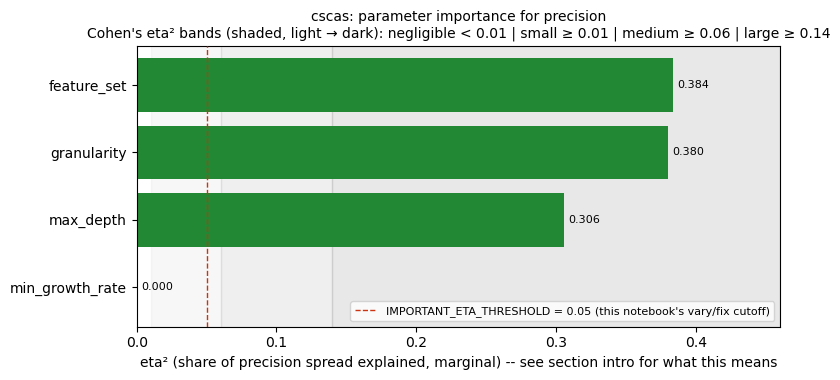

In [29]:
IMPORTANT_COLOR = "#228833"
FIXED_COLOR = "#BBBBBB"

plot_importance = importance.dropna(subset=["eta_squared"]).sort_values("eta_squared")
bar_colors = [
    IMPORTANT_COLOR if v >= IMPORTANT_ETA_THRESHOLD else FIXED_COLOR
    for v in plot_importance["eta_squared"]
]

fig, ax = plt.subplots(figsize=(8, 0.6 * len(plot_importance) + 1.5))

# Cohen's-convention background bands (see effect_size_label) so eta²'s
# magnitude reads against a standard reference scale, not just relative to
# IMPORTANT_ETA_THRESHOLD's ad hoc cutoff (dashed line below).
x_max = max(plot_importance["eta_squared"].max(), EFFECT_SIZE_THRESHOLDS["large"]) * 1.2
band_edges = [
    0.0,
    EFFECT_SIZE_THRESHOLDS["small"],
    EFFECT_SIZE_THRESHOLDS["medium"],
    EFFECT_SIZE_THRESHOLDS["large"],
    x_max,
]
band_labels = ["negligible", "small", "medium", "large"]
for lo, hi, label, alpha in zip(band_edges[:-1], band_edges[1:], band_labels, [0.0, 0.06, 0.12, 0.18]):
    ax.axvspan(lo, hi, color="gray", alpha=alpha, zorder=0)
# Bands below "medium" are usually too narrow for an in-band label at this
# scale -- name all four once, in the title, instead of packing text into
# slivers that would overlap.
band_caption = " | ".join(
    f"{label} ≥ {edge:g}" if edge > 0 else f"{label} < {EFFECT_SIZE_THRESHOLDS['small']:g}"
    for label, edge in zip(band_labels, band_edges[:-1])
)

bars = ax.barh(plot_importance["parameter"], plot_importance["eta_squared"], color=bar_colors, zorder=2)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.axvline(
    IMPORTANT_ETA_THRESHOLD,
    color=FLOOR_LINE_COLOR,
    linestyle="--",
    linewidth=1,
    label=f"IMPORTANT_ETA_THRESHOLD = {IMPORTANT_ETA_THRESHOLD} (this notebook's vary/fix cutoff)",
    zorder=3,
)
ax.set_xlim(0, x_max)
ax.set_xlabel(f"eta² (share of {SCORE_COL} spread explained, marginal) -- see section intro for what this means")
ax.set_title(
    f"{SCENARIO}: parameter importance for {SCORE_COL}\n"
    f"Cohen's eta² bands (shaded, light → dark): {band_caption}",
    fontsize=10,
)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

### Main effects

Same grouping as the eta² table, laid out per-parameter instead of
collapsed to one number: mean ± std of `score_mean` at each level, marginalized
over every other parameter. A parameter with a high eta² should visibly
separate its bars here; a low-eta² parameter's bars should look flat within
noise -- this is the plot to put next to the eta² table when defending "we
fixed X" in the thesis.

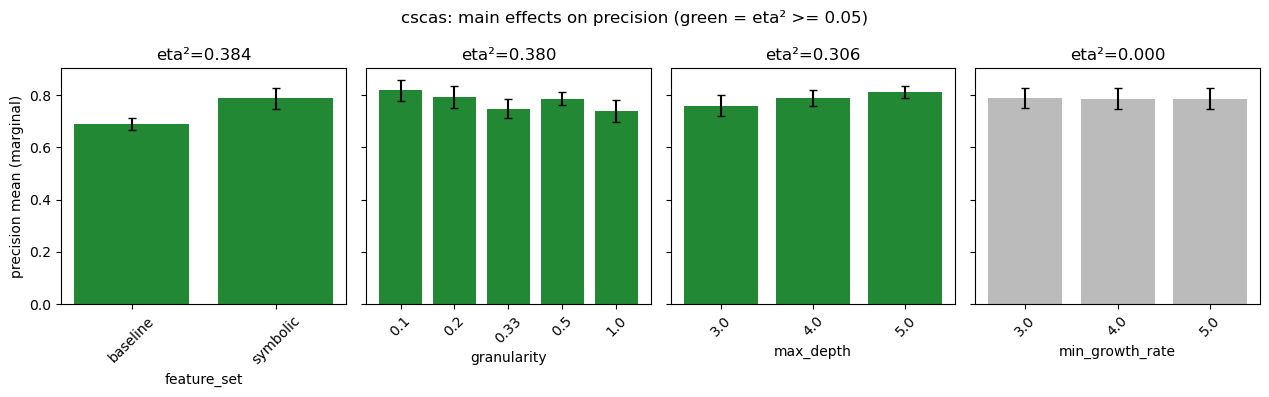

In [30]:
effects = main_effects(summary_expanded, score_col="score_mean", param_cols=PARAM_COLS)

# Only parameters this sweep actually varied (n_levels >= 2, i.e. a real
# eta_squared) get a panel -- a fixed-by-omission parameter (e.g.
# min_samples_leaf) would just be one trivial single-bar plot; it's already
# called out in the "not screened" list in the recommendation cell below.
params_with_data = list(importance.dropna(subset=["eta_squared"])["parameter"])
n_params = len(params_with_data)
fig, axes = plt.subplots(1, n_params, figsize=(3.2 * n_params, 4), sharey=True)
if n_params == 1:
    axes = [axes]

for ax, param in zip(axes, params_with_data):
    group = effects[effects["parameter"] == param].sort_values("level")
    eta_sq = importance.loc[importance["parameter"] == param, "eta_squared"].iloc[0]
    color = IMPORTANT_COLOR if pd.notna(eta_sq) and eta_sq >= IMPORTANT_ETA_THRESHOLD else FIXED_COLOR
    ax.bar(group["level"].astype(str), group["mean"], yerr=group["std"], capsize=3, color=color)
    ax.set_xlabel(param)
    eta_label = f"{eta_sq:.3f}" if pd.notna(eta_sq) else "n/a"
    ax.set_title(f"eta²={eta_label}")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel(f"{SCORE_COL} mean (marginal)")
fig.suptitle(f"{SCENARIO}: main effects on {SCORE_COL} (green = eta² >= {IMPORTANT_ETA_THRESHOLD})")
fig.tight_layout()

### Recommendation: vary vs. fix

Splits `PARAM_COLS` by `IMPORTANT_ETA_THRESHOLD` and, for each parameter to
fix, reports the level the top-`K` shortlist (section 2) actually converged
on -- the concrete value to write into Experiments 2-4's config, not just
"fix this axis".

In [31]:
shortlist_expanded = expand_named_setting(shortlist, mining_param_map, col="mining_setting")

vary = importance.loc[importance["eta_squared"] >= IMPORTANT_ETA_THRESHOLD, "parameter"].tolist()
not_screened = importance.loc[importance["eta_squared"].isna(), "parameter"].tolist()
fix = importance.loc[
    importance["eta_squared"].notna() & (importance["eta_squared"] < IMPORTANT_ETA_THRESHOLD),
    "parameter",
].tolist()

print(f"Vary in Experiments 2-4 (eta² >= {IMPORTANT_ETA_THRESHOLD}):")
for p in vary:
    row = importance.loc[importance["parameter"] == p].iloc[0]
    print(f"  {p}: eta²={row['eta_squared']:.3f}, p={row['p_value']:.2g}, effect_range={row['effect_range']:.3f}")

print(f"\nFix at the shortlist's winning level (eta² < {IMPORTANT_ETA_THRESHOLD}):")
for p in fix:
    winning = shortlist_expanded[p].mode().tolist() if p in shortlist_expanded.columns else "?"
    print(f"  {p}: fix at {winning}")

if not_screened:
    print(f"\nNot screened here (single level in this sweep): {not_screened}")
    print("  -- e.g. model=logreg (see prior rationale for excluding alternatives) or a")
    print("  mining threshold the YAML never varies (fixed by omission, not by evidence).")

Vary in Experiments 2-4 (eta² >= 0.05):
  feature_set: eta²=0.384, p=1.6e-06, effect_range=0.098
  granularity: eta²=0.380, p=0.0002, effect_range=0.079
  max_depth: eta²=0.306, p=0.00047, effect_range=0.052

Fix at the shortlist's winning level (eta² < 0.05):
  min_growth_rate: fix at [3.0]

Not screened here (single level in this sweep): ['model', 'class_weight', 'max_p_value', 'min_attack_coverage', 'min_benign_coverage', 'min_impurity_decrease', 'min_samples_leaf', 'random_state']
  -- e.g. model=logreg (see prior rationale for excluding alternatives) or a
  mining threshold the YAML never varies (fixed by omission, not by evidence).


## 10. Reduced shortlist: fix the negligible parameters, keep full coverage on the rest

The recommendation above identifies `fix`-worthy parameters (eta² below
`IMPORTANT_ETA_THRESHOLD`, evidence-backed -- not the separate `not_screened`
bucket, which has no real evidence either way) and the level the top-`K`
shortlist already converged on for each. This section builds a *second*
shortlist that pins every `fix` parameter to that level while leaving every
`vary` parameter (here: `granularity`, `max_depth`, `feature_set`)
completely untouched -- every combination of what matters, none of the
redundant repeats of what doesn't.

`thesis.metrics.sensitivity.restrict_to_fixed_levels` does the filtering
generically: it takes any `{parameter: winning_level}` dict and drops rows
that used a different level of those parameters specifically, so this isn't
hardcoded to `min_growth_rate` -- rerun this notebook on a sweep where a
different parameter turns out negligible and the same cell produces the
right filter. Baseline configs have no mining-derived parameter value to
match against, so they're always kept.

Saved to its own file (`shortlist_reduced.csv`), alongside the original
top-`K` `shortlist.csv` -- point Experiment 2 at whichever fits your compute
budget (see the runtime discussion earlier in this session: fixing
`min_growth_rate` alone cut a full-sweep Experiment 2 run from ~5h to ~2.2h
estimated, without dropping a single `granularity`/`max_depth` combination).

In [32]:
from thesis.metrics.sensitivity import restrict_to_fixed_levels

fixed_levels = {
    p: shortlist_expanded[p].mode().iloc[0]
    for p in fix
    if p in shortlist_expanded.columns and not shortlist_expanded[p].mode().empty
}
print("Fixing:", fixed_levels or "(nothing to fix -- no evidence-backed negligible parameters this run)")

ranked_expanded = expand_named_setting(ranked, mining_param_map, col="mining_setting")
reduced = restrict_to_fixed_levels(ranked_expanded, fixed_levels)
reduced = apply_floor_check(reduced, floor_threshold=FLOOR_THRESHOLD, floor_col=FLOOR_COL)

n_failing_reduced = (~reduced["passes_floor"]).sum()
print(
    f"Reduced shortlist: {len(reduced)} configs (from {len(ranked)} total), "
    f"{n_failing_reduced} failing the floor check -- inspect before finalizing."
    if n_failing_reduced
    else f"Reduced shortlist: {len(reduced)} configs (from {len(ranked)} total), all clear the floor check."
)

REDUCED_SHORTLIST_PATH = sweep_dir / "shortlist_reduced.csv"
reduced_out = reduced[["feature_set", "mining_setting", "granularity", "model"]]
reduced_out.to_csv(REDUCED_SHORTLIST_PATH, index=False)
print(f"Saved reduced shortlist ({len(reduced_out)} configs) → {REDUCED_SHORTLIST_PATH}")
reduced_out

Fixing: {'min_growth_rate': 3.0}
Reduced shortlist: 20 configs (from 50 total), 2 failing the floor check -- inspect before finalizing.
Saved reduced shortlist (20 configs) → /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/screening_sweep/cscas/shortlist_reduced.csv


,feature_set,mining_setting,granularity,model
2,symbolic,gr3.0_md5,0.10,logreg
3,symbolic,gr3.0_md5,0.20,logreg
7,symbolic,gr3.0_md4,0.10,logreg
9,symbolic,gr3.0_md5,0.50,logreg
14,symbolic,gr3.0_md5,1.00,logreg
15,symbolic,gr3.0_md4,0.50,logreg
18,symbolic,gr3.0_md4,0.20,logreg
22,symbolic,gr3.0_md3,0.10,logreg
26,symbolic,gr3.0_md5,0.33,logreg
31,symbolic,gr3.0_md4,1.00,logreg
